In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
import numpy as np

In [8]:
(x_train, y_train),(x_test, y_test) = mnist.load_data() 

In [13]:
x_tain = x_train/255.0
x_test = x_test/255.0

In [14]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [15]:
print("X Train Shape",x_train.shape)
print("X Test Shape",x_test.shape)

X Train Shape (60000, 28, 28, 1)
X Test Shape (10000, 28, 28, 1)


In [38]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        name="conv1"
    ),

    keras.layers.MaxPooling2D(
        (2, 2),
        name="pool1"
    ),

    keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        name="conv2"
    ),

    keras.layers.MaxPooling2D(
        (2, 2),
        name="pool2"
    ),

    keras.layers.Flatten(),

    keras.layers.Dense(
        64,
        activation="relu"
    ),

    keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [40]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9392 - loss: 0.2890 - val_accuracy: 0.9767 - val_loss: 0.0887
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9807 - loss: 0.0622 - val_accuracy: 0.9827 - val_loss: 0.0636
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9852 - loss: 0.0484 - val_accuracy: 0.9857 - val_loss: 0.0593
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9878 - loss: 0.0400 - val_accuracy: 0.9887 - val_loss: 0.0490
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9822 - val_loss: 0.0806
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9907 - loss: 0.0306 - val_accuracy: 0.9855 - val_loss: 0.0608
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9917 - loss: 0.0263 - val_accuracy: 0.9870 - val_loss: 0.0696
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9929 -

In [41]:
index = 0

image = x_test[index]
label = y_test[index]

print("Actual Label:", label)
print("Image Shape:", image.shape)

Actual Label: 7
Image Shape: (28, 28, 1)


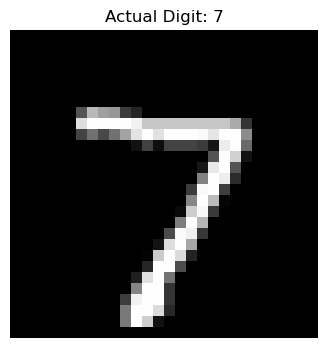

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))

plt.imshow(
    x_test[index].squeeze(), cmap='grey'
),

plt.title(f"Actual Digit: {y_test[index]}")

plt.axis("off")
plt.show()

In [44]:
feature_input = keras.Input(shape=(28, 28, 1))

x = model.get_layer("conv1")(feature_input)
conv1_output = x

x = model.get_layer("pool1")(x)

x = model.get_layer("conv2")(x)
conv2_output = x

feature_model = keras.Model(
    inputs=feature_input,
    outputs=[
        conv1_output,
        conv2_output
    ]
)

In [45]:
feature_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 14, 14, 64)          │          18,496 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
index = 0

image_input = x_test[index:index+1]

print(image_input.shape)

(1, 28, 28, 1)


In [47]:
feature_maps = feature_model.predict(
    image_input,
    verbose=0
)

In [48]:
first_layer_features = feature_maps[0]
second_layer_features = feature_maps[1]

print(
    "First Conv:",
    first_layer_features.shape
)

print(
    "Second Conv:",
    second_layer_features.shape
)

First Conv: (1, 28, 28, 32)
Second Conv: (1, 14, 14, 64)


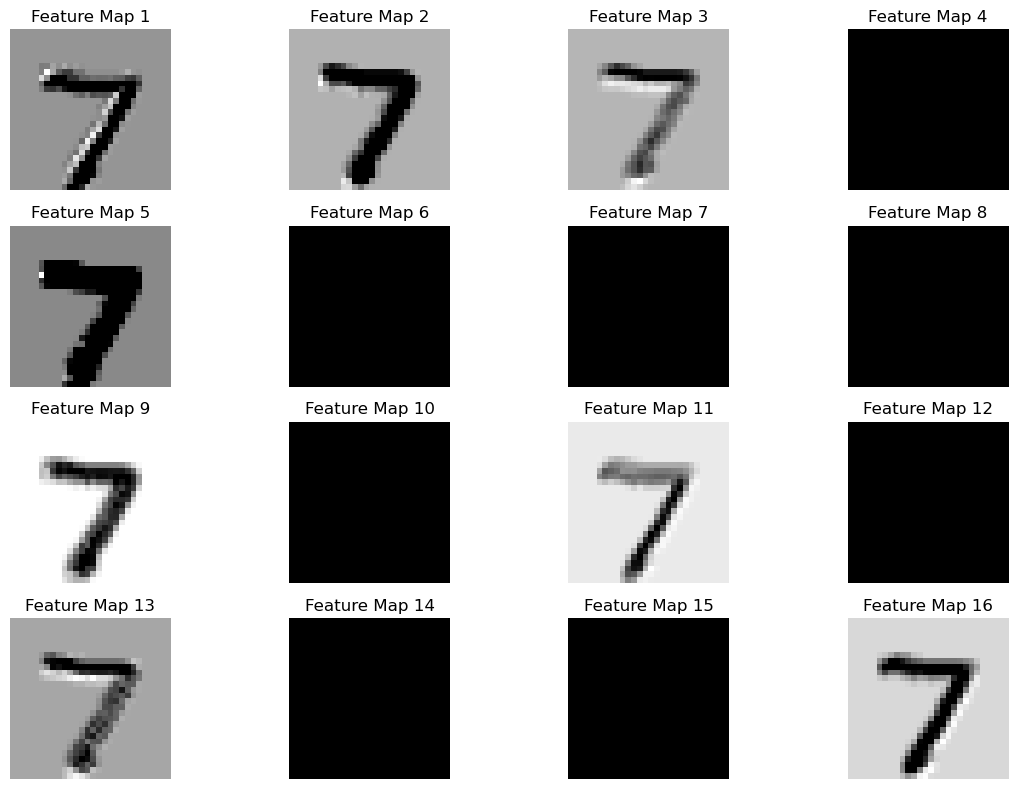

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        first_layer_features[0, :, :, i],
        cmap="gray"
    )

    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()